A continuacion se obtienen los resultados numericos para una red de cuatro spin-torque nano-oscillators

In [26]:
################################################################
#           STNO LIBRE (Modelo tipo Van Der Pol)               #
################################################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import ListedColormap


Para este primer resultado debemos considerar que no existe acoplamiento con otros osciladores (Solo tenemos 1 oscilador). Por tanto, la dinamica del sistema es gobernada por: 

$$\frac{ds}{dt}=-\alpha \omega_{0} \left( 1-\frac{I}{I_{th}}+Qs^{2} \right)s   \\ 
   
\frac{d\theta}{dt}=\omega_{0}(1+N_{0}s^{2}) $$

donde $s$ representa el radio de la orbita, $\theta$ es el angulo asociado a la posicion del vortice, $\alpha$ coeficiente de damping, $\omega_{0}$ es la frecuencia natural del STNO, $I$ es la corriente inyectada al STNO, $I_{th}$ es la corriente de umbral para que se produzca una auto-oscilacion, $Q$ parametro de damping no lineal y $N_{0}$ el corrimiento de frecuencia no lineal normalizado por la frecuencia angular natural. 

Por simplicidad trabajaremos con el tiempo adimensional, definiendo: 

$$
\tau=\omega_{0}t 
\qquad \implies \qquad 
\frac{d}{dt} = \omega_{0} \frac{d}{d\tau}
$$  

De esta manera, las ecuaciones correspondientes son tales que:

$$
\begin{aligned}
\frac{ds}{d \tau}
&=-\alpha \left(1-\frac{I}{I_{th}}+Qs^{2}\right)s,\\
\frac{d \theta}{d \tau}
&=1+N_{0}s^{2}.
\end{aligned}
$$

In [27]:
################################################################
#             Parametros (Entregados por suplemento)           #
################################################################

alpha=0.013
Q=3.02
Ith=1                                       #mA
I=1.5*Ith                                   #La corriente inyectada al inicio de la dinamica no se conoce, asi que elijo yo una
N_0=0.08

Antes de integrar y calcular la dinámica del ciclo, podemos obtener la solución
estacionaria del valor del radio de la órbita. Para ello:

$$
\frac{ds}{d\tau}=0
\qquad \implies \qquad
-\alpha \left(1-\frac{I}{I_{th}}+Qs^{2}\right)s=0.
$$

De esta manera, obtenemos dos soluciones estacionarias:

$$
s_{ss}=0,
$$

y, para la solución no trivial:

$$
s_{ss}=\sqrt{\frac{I/I_{th}-1}{Q}}.
$$

In [28]:
s_ss=np.sqrt(((I/Ith)-1)/Q)

print(f"Radio estacionario teórico: s_lc = {s_ss:.6f}")

Radio estacionario teórico: s_lc = 0.406894


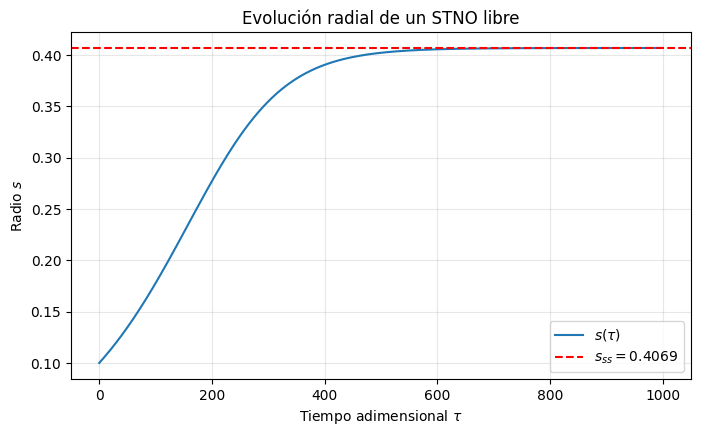

Radio final numérico:  0.406887
Radio teórico:         0.406894
Error absoluto:        7.154e-06


In [29]:
################################################################
#                     Ecuaciones diferenciales                 #
################################################################

Irazon=I/Ith

def STNO_libre(tau, y, alpha, Q, N_0, Irazon):
    s, theta=y
    ds_dtau=-alpha*(1-Irazon + Q*s**2)*s                          #Radio
    dtheta_dtau=1+N_0 * s**2                                      #Angulo
    return [ds_dtau, dtheta_dtau]                                 #Arreglo de soluciones

#Condiciones iniciales (Elecciones hechas por mi)

s_0=0.1
theta0=0
y_0=[s_0, theta0]

#Arreglo temporal

tau_0=0
tau_f=1000
tau_arreglo=np.linspace(tau_0, tau_f, 10000)

#Solucion

sol = solve_ivp(fun=STNO_libre, t_span=(tau_0, tau_f), y0=y_0, t_eval=tau_arreglo, args=(alpha, Q, N_0, Irazon), method="RK45", rtol=1e-9, atol=1e-11)

#Arreglo de soluciones

tau=sol.t
s=sol.y[0]
theta=sol.y[1]

#Grafico de la evolucion del radio de la orbita

plt.figure(figsize=(8, 4.5))
plt.plot(tau, s, label=r"$s(\tau)$")
plt.axhline(s_ss,color="red",linestyle="--",label=rf"$s_{{ss}}={s_ss:.4f}$")
plt.xlabel(r"Tiempo adimensional $\tau$")
plt.ylabel(r"Radio $s$")
plt.title("Evolución radial de un STNO libre")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Radio final numérico:  {s[-1]:.6f}")
print(f"Radio teórico:         {s_ss:.6f}")
print(f"Error absoluto:        {abs(s[-1] - s_ss):.3e}")

Ahora que ya sabemos que la solucion numerica converge a la teorica de buena manera, queremos visualizar la trayectoria de la orbita hasta la estabilidad. Para ello, utilizamos coordenadas polares tal que:

$$
x(\tau)=s(\tau)cos(\theta (\tau)) \qquad \qquad y(\tau)=s(\tau)sin(\theta (\tau))
$$

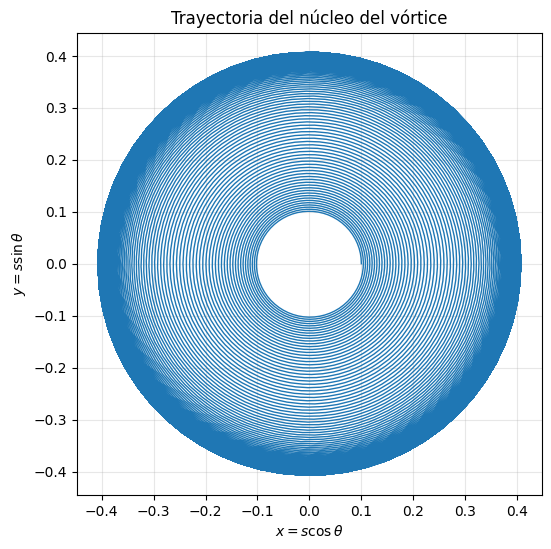

Radio inicial numérico:  0.100000
Radio final numérico:  0.406887


In [30]:
################################################################
#                         Trayectoria                          #
################################################################

x=s*np.cos(theta)
y=s*np.sin(theta)

plt.figure(figsize=(6, 6))
plt.plot(x, y, linewidth=1.0, color="tab:blue")
plt.xlabel(r"$x=s\cos\theta$")
plt.ylabel(r"$y=s\sin\theta$")
plt.title("Trayectoria del núcleo del vórtice")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.show()

print(f"Radio inicial numérico:  {s[0]:.6f}")
print(f"Radio final numérico:  {s[-1]:.6f}")

Podemos observar como el radio comienza con un valor de 0.1 y evoluciona al valor estacionario 0.41, que era lo esperado. Sin embargo, para la evolucion del sistema nos interesa la parte final, es decir, la forma estacionario. Esto es porque son estas las que perduran como auto-oscilacion y posteriormente, se acoplan a frecuencias externas (Locking range). 

In [31]:
################################################################
#           Frecuencia estacionaria STNO libre                 #
################################################################

Posiciones_ss=int(0.8*len(tau))                                               #Tomo el ultimo 20% de la simulacion
tau_ss=tau[Posiciones_ss:]
theta_ss=theta[Posiciones_ss:]

Omega_num=(theta_ss[-1]-theta_ss[0])/(tau_ss[-1]-tau_ss[0])
Omega_teo=1+N_0*s_ss**2

print(f"Frecuencia angular numérica: {Omega_num:.8f}")
print(f"Frecuencia angular teórica:  {Omega_teo:.8f}")
print(f"Error absoluto: {abs(Omega_num-Omega_teo):.3e}")

Frecuencia angular numérica: 1.01324280
Frecuencia angular teórica:  1.01324503
Error absoluto: 2.230e-06


Ahora podemos analizar que sucede cuando inyectamos una frecuencia externa al sistema, llamemosla $f_{A}$ (En nuestro caso esto es representado por $\varepsilon =0$ y $F_{e} \neq 0$). De esta manera, las ecuaciones que describen el sistema son:

$$
\begin{aligned}
\frac{ds}{d \tau}
&=-\alpha \left(1-\frac{I}{I_{th}}+Qs^{2}\right)s
+F_{e}\cos{\theta}\cos(\psi_{e}-\Omega_{e}\tau)
\end{aligned}
$$

$$
\frac{d \theta}{d \tau} =1+N_{0}s^{2} + \frac{F_{e}}{s}\sin{\theta}\cos(\psi_{e}-\Omega_{e}\tau)
$$

donde $F_{e}$ es la fuerza de acoplamiento con la señal $f_{A}$, $\psi_{e}$ es el corrimiento de fase relativo (que consideraremos nulo) y $\Omega_{e}=\frac{\omega_{e}}{\omega_{0}}$ es la frecuencia angular externa normalizada.

In [32]:
################################################################
#                 Parametros de la excitacion                  #
################################################################

F_e=1.3e-3
psi_e=0
Omega_libre=Omega_teo
Omega_e=1.01                                                          #Elegimos una frecuencia angular externa ligeramente distinta a la libre
delta=Omega_e-Omega_libre                                            #Detuning

################################################################
#                 STNO con excitacion externa                  #
################################################################

def STNO_frec_ext(tau, y, alpha, Q, N_0, Irazon, F_e, Omega_e, psi_e):
    s, theta=y
    Externo= F_e*np.cos(psi_e-Omega_e*tau)
    ds_dtau=-alpha*(1-Irazon + Q*s**2)*s +Externo*np.cos(theta)                         #Radio
    dtheta_dtau=1+N_0 * s**2+ (Externo*np.sin(theta))/s                                 #Angulo
    return [ds_dtau, dtheta_dtau]                                                       #Arreglo de soluciones

################################################################
#                     Resolucion del sistema                   #
################################################################

s_0_frec_ext=s_ss                                                      #Establecemos que el radio inicial sera la frecuencia angular estacionaria (auto-oscilacion sostenida)
theta_0_frec_ext=0

#Condiciones iniciales de integracion

y_0_frec_ext=[s_0_frec_ext, theta_0_frec_ext]                 

#Arreglo temporal

tau_0=0
tau_f=5000
tau_arreglo=np.linspace(tau_0, tau_f, 50000)

#Solucion

sol_frec_ext = solve_ivp(fun=STNO_frec_ext, t_span=(tau_0, tau_f), y0=y_0_frec_ext, t_eval=tau_arreglo, args=(alpha, Q, N_0, Irazon, F_e, Omega_e, psi_e), method="RK45", rtol=1e-9, atol=1e-11)
tau_frec_ext=sol_frec_ext.t
s_frec_ext=sol_frec_ext.y[0]
theta_frec_ext=sol_frec_ext.y[1]

################################################################
#     Frecuencia estacionaria STNO con excitacion externa      #
################################################################

Posiciones_ss_frec_ext=int(0.8*len(tau_frec_ext))                                               #Tomo el ultimo 20% de la simulacion
tau_ss_frec_ext=tau_frec_ext[Posiciones_ss_frec_ext:]
theta_ss_frec_ext=theta_frec_ext[Posiciones_ss_frec_ext:]
Omega_STNO=(theta_ss_frec_ext[-1]-theta_ss_frec_ext[0])/(tau_ss_frec_ext[-1]-tau_ss_frec_ext[0])

print(f"Frecuencia libre:    {Omega_libre:.8f}")
print(f"Frecuencia externa:  {Omega_e:.8f}")
print(f"Frecuencia STNO:     {Omega_STNO:.8f}")
print("Diferencia STNO-fuente: "f"{abs(Omega_STNO - Omega_e):.3e}")


Frecuencia libre:    1.01324503
Frecuencia externa:  1.01000000
Frecuencia STNO:     1.00999825
Diferencia STNO-fuente: 1.745e-06


Notemos que el STNO libre tiene una frecuencia de oscilacion natural distinta a la frecuencia de oscilacion modificada o desplazada por la accion de la señal externa $f_{A}$. Sin embargo, no tenemos una metrica que nos permita decir que existe sincronizacion. Es por ello que ahora analizaremos la fase relativa, la cual nos dira si existe un phase locking. Se define entonces: 

$$
\phi(\tau)=\theta(\tau)-\Omega_{e}\tau+\psi_{e}
$$

En particular, se considera un corrimiento de fase relativo $\psi_{e}$ nulo. De esta manera, la fase relativa:

$$
\phi(\tau)=\theta(\tau)-\Omega_{e}\tau
$$

Si conforme pasa el tiempo $\phi \rightarrow C$ (donde $C$ es una constante) se presenta el fenomeno de phase locking, que nos indica que existe un proceso de sincronizacion en el sistema, donde el oscilar acoplado a la frecuencia externa modifica su frecuancia de oscilacion, acercandose asi a la frecuencia externa.

$$
\Omega_{STNO} \rightarrow \Omega_{e}
$$

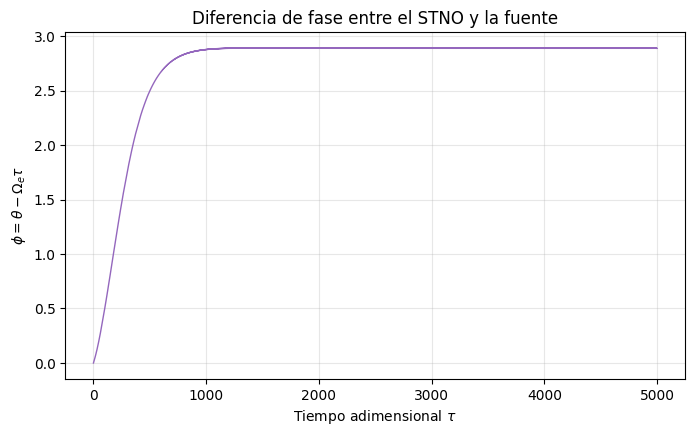

Diferencia de frecuencia STNO-fuente final: 2.887e+00


In [33]:
################################################################
#                       Fase relativa                          #
################################################################

phi=theta_frec_ext-Omega_e*tau_frec_ext 

plt.figure(figsize=(8, 4.5))
plt.plot(tau_frec_ext,phi,color="tab:purple",linewidth=1.0)
plt.xlabel(r"Tiempo adimensional $\tau$")
plt.ylabel(r"$\phi=\theta-\Omega_e\tau$")
plt.title("Diferencia de fase entre el STNO y la fuente")
plt.grid(alpha=0.3)
plt.show()

print("Diferencia de frecuencia STNO-fuente final: "f"{phi[-1]:.3e}")

Observemos que para este caso particular a partir de $\tau=1000$ aproximadamente en adelante se presenta un phase locking, lo cual queda en evidencia al comparar la diferencia de frecuencias de la frecuencia externa con la del oscilador luego de que interactuen. Sin embargo, falta determinar cual es el locking range, es decir, el rango de diferencia de frecuencias de oscilacion donde se produce un phase locking. Para ello debemos hacer un barrido de frecuencias externas y establecer un criterio de sincronizacion para asi determinar un locking range. Definimos entonces:

$$
E_{\Omega}=|\Omega_{STNO}-\Omega_{e}|
$$

Y, donde establecemos que existe un bloqueo de frecuencia para valores $E_{\Omega}< 10^{-4}$ (establezco este por que el caso analizado de phase locking entrego un $E_{\Omega} \approx 1.75^{-6}$)

In [34]:
################################################################
#         Funcion para simular frecuencias externas            #
################################################################

def sim_fe(Omega_e_i, tau_final, pasos):
    tau_evaluado=np.linspace(0, tau_final, pasos)                                     #Arreglo de tiempos
    solucion=solve_ivp(fun=STNO_frec_ext, t_span=(0.0, tau_final), y0=[s_ss, 0.0], t_eval=tau_evaluado, args=(alpha, Q, N_0, Irazon, F_e, Omega_e_i, psi_e), method="RK45", rtol=1e-8, atol=1e-10)
    tau_actual=solucion.t                                                        #Tiempo de cierto paso
    theta_actual=solucion.y[1]                                                   #Angulo de cierto tiempo
    Posiciones_ss=int(0.8*len(tau_actual))                                       #Tomamos el ultimo 20% de la simulacion
    tau_ss=tau_actual[Posiciones_ss:]                                
    theta_ss=theta_actual[Posiciones_ss:]
    Omega_STNO=(theta_ss[-1]-theta_ss[0])/(tau_ss[-1]-tau_ss[0])                 #Frecuencia de STNO en estado estacionario
    error_frec=abs(Omega_STNO-Omega_e_i)                                         #E_{\Omega}
    phi_ss=theta_ss-Omega_e_i*tau_ss                                             #Fase relativa

    #Lo que necesitamos ahora es la tasa de cambio de fase relativa. Para ello aplicare la funcion polyfit (ajuste lineal)

    pendiente_phi = np.polyfit(tau_ss, phi_ss, 1)[0]

    return Omega_STNO, error_frec, pendiente_phi

#Para corroborar que la funcion retorna los valores correctos haremos una prueba con el valor de la frecuencia externa analizada anteriormente

Omega_prueba=1.010
Omega_STNO_prueba, error_prueba, pendiente_prueba=(sim_fe(Omega_prueba, 5000, 10000))

print(f"Frecuencia externa:       {Omega_prueba:.8f}")
print(f"Frecuencia del STNO:      {Omega_STNO_prueba:.8f}")
print(f"Error de frecuencia:      {error_prueba:.3e}")
print(f"Pendiente de fase:        {pendiente_prueba:.3e}")

Frecuencia externa:       1.01000000
Frecuencia del STNO:      1.00999829
Error de frecuencia:      1.712e-06
Pendiente de fase:        -4.974e-10


Se observa un proceso de sincronizacion que cumple con la condicion correspondiente de $E_{\Omega}$.

Ahora analizaremos una red de cuatro STNOs. Las ecuaciones que gobiernan la dinamica del sistema son tal que:

$$
\frac{ds_{i}}{d\tau}=-\alpha \Omega_{0,i}(1-\frac{I}{I_{th}}+Qs_{i}^{2})s_{i}+F_{e}\cos(\theta_{i})(\cos(\psi_{A}-\Omega_{A}\tau)+\cos(\psi_{B}-\Omega_{B}\tau))+\varepsilon F_{e} \cos(\theta_{i})\sum_{j=1}^{4}s_{j}\cos(\theta_{j})
$$ 

$$
\frac{d\theta_{i}}{d\tau}=\Omega_{0,i}(1+N_{0}s_{i}^{2})+\frac{F_{e}}{s_{i}}\sin(\theta_{i})(\cos(\psi_{A}-\Omega_{A}\tau)+\cos(\psi_{B}-\Omega_{B}\tau))+\varepsilon \frac{F_{e}}{s_{i}}\sin(\theta_{i})\sum_{j=1}^{4}s_{j}\cos(\theta_{j})
$$  

Donde $\Omega_{0,1}$ son las frecuencias naturales de oscilacion de los osciladores y $\varepsilon$ es el factor de acoplamiento.

In [35]:
################################################################
#           Parametros de la red de cuatro STNOs               #
################################################################

Num_STNO=4
Omega_0=np.array([0.97, 0.99, 1.01, 1.03])                                 #El material suplementario solo menciona que las frecuencias naturales de los STNO se separan aproximadamente un 2%
psi_A=0                                                                    #Corrimientos de fase para frecuencia externa f_{A} y f_{B}
psi_B=0
epsilon=1.6                                                                #Factor de acoplamiento obtenido de la figura 3c-d

################################################################
#                      Red de cuatro STNOs                     #
################################################################

def red_4_STNOs(tau, y, alpha, Q, N_0, Irazon, F_e, epsilon, Omega_0, Omega_A, Omega_B, psi_A, psi_B):                      #Aqui y=(s_1, \theta_1,..., s_4, \theta_4)
    s=y[0::2]                                                               #Arreglo de radios
    theta=y[1::2]                                                           #Arreglo de angulos
    señal_A=np.cos(psi_A-Omega_A*tau)                                       #Señales
    señal_B=np.cos(psi_B-Omega_B*tau)
    señal_total=señal_A+señal_B
    acopl_osc=np.sum(s*np.cos(theta))                                       #Acoplamiento tipo Kuramoto

    #Ecuaciones de movimiento

    ds_dtau=(-alpha*Omega_0*(1-Irazon +Q*s**2)*s+F_e*np.cos(theta)*señal_total+epsilon*F_e*np.cos(theta)*acopl_osc)
    dtheta_dtau=(Omega_0*(1+N_0*s**2)+(F_e/s)*np.sin(theta)*señal_total+epsilon*(F_e/s)*np.sin(theta)*acopl_osc)

    soluciones=np.empty(2*Num_STNO)                                         #Construyo arreglo de soluciones
    soluciones[0::2]=ds_dtau
    soluciones[1::2]=dtheta_dtau

    return soluciones

################################################################
#            Frecuencias libres de los cuatro STNOs            #
################################################################

s_ss_red=np.sqrt((Irazon-1.0)/Q)
Omega_libres_red=Omega_0*(1.0+N_0*s_ss_red**2)

for i, Omega_libre_i in enumerate(Omega_libres_red):
    print(f"Frecuencia libre STNO {i+1}: "f"{Omega_libre_i:.8f}")


Frecuencia libre STNO 1: 0.98284768
Frecuencia libre STNO 2: 1.00311258
Frecuencia libre STNO 3: 1.02337748
Frecuencia libre STNO 4: 1.04364238


Dado que ya tenemos la funcion que nos entregara un arreglo de soluciones tanto para el radio como el angulo podemos buscar ahora las frecuencias estacionarias de cada oscilador cuando inyectamos dos frecuencias o señales externas

In [ ]:
################################################################
#             Simulacion de un punto del mapa                  #
################################################################

def frec_ss(Omega_A, Omega_B, tau_final, pasos):
    s_iniciales=np.full(Num_STNO, s_ss_red)                                         #Arreglo de radios estacionarios
    theta_iniciales=np.array([0, 0.05, 0.1, 0.15])                                  #Elijo un desfase minimo entre osciladores
    y_inicial=np.empty(2*Num_STNO)                                                  #Vector de 8 elementos itercalados y=(s_1, theta_1,...,s_4, theta_4)
    y_inicial[0::2]=s_iniciales
    y_inicial[1::2]=theta_iniciales
    tau_evaluado=np.linspace(0, tau_final, pasos)                                   #Arreglo de tiempos
    solucion=solve_ivp(fun=red_4_STNOs, t_span=(0.0, tau_final), y0=y_inicial, t_eval=tau_evaluado, args=(alpha, Q, N_0, Irazon, F_e, epsilon, Omega_0, Omega_A, Omega_B, psi_A, psi_B), method="RK45", rtol=1e-8, atol=1e-10)
    tau_arreglo=solucion.t
    theta_sol=solucion.y[1::2]

    #Tomamos el ultimo 20% de la simulacion

    Posiciones_ss=int(0.8*len(tau_arreglo))
    tau_ss=tau_arreglo[Posiciones_ss:]
    theta_ss = theta_sol[:,Posiciones_ss:]

    #Frecuencias de los STNOs

    Omega_STNOs=(theta_ss[:, -1]-theta_ss[:, 0])/(tau_ss[-1]-tau_ss[0])             #Arreglo de frecuencias de los STNOs

    return (Omega_STNOs, tau_arreglo, solucion.y)

#Ahora necesitamos clasificar si existe o no sincronizacion, para ello utilizaremos E_{\Omega}

def clasificacion(Omega_STNOs, Omega_A, Omega_B, tol=tolerancia):
    patron_clas=np.zeros(Num_STNO, dtype=int)                                       #Construyo arreglo para los patrones de clasificacion

    for i in range(Num_STNO):
        error_A=abs(Omega_STNOs[i]-Omega_A)                                         #Error de frecuencias respecto a A y B
        error_B=abs(Omega_STNOs[i]-Omega_B)
        if (error_A<tol and error_A<=error_B):
            patron_clas[i]=1                                                        #Oscilador sincronizado con señal A (1)
        elif error_B<tol:
            patron_clas[i]=2                                                        #Oscilador sincronizado con señal B (2)

    return patron_clas   

#Prueba. Señales externas iguales a frecuencias naturales libres de STNO 1 y 2

Omega_A_prueba = Omega_libres_red[1]
Omega_B_prueba = Omega_libres_red[2]

(Omega_STNOs_prueba, tau_prueba, solucion_prueba)=frec_ss(Omega_A_prueba, Omega_B_prueba, 5000, 10000)
patron_prueba=clasificacion(Omega_STNOs_prueba, Omega_A_prueba, Omega_B_prueba)

print("Patrón de sincronización:", patron_prueba)     
print("Frecuencias estacionarios de los STNOs:", Omega_STNOs_prueba)     
                                      

Patrón de sincronización: [0 1 2 0]
Frecuencias estacionarios de los STNOs: [0.985037 1.003127 1.023412 1.045831]


Ya tenemos una funcion para encontrar las frecuencias estacionarias de los osciladores y tambien una funcion para clasificar patrones de sincronizacion. El proximo paso es extender esto a un mapa bidimensional que muestre regiones de sincronizacion para distintos pares de frecuencias externas. Para ello, primero crearemos una funcion que nos devuelva el patron existente para un par de frecuencias externas:

In [37]:
def Patron_particular(Omega_A, Omega_B, tau_final=5000.0, numero_puntos=10000, tolerancia=tolerancia):
    Omega_STNOs,_,_=frec_ss(Omega_A, Omega_B, tau_final, numero_puntos)                      #Solo nos interesa las frecuencias de los STNOs
    patron=clasificacion(Omega_STNOs, Omega_A, Omega_B, tolerancia)

    return patron

Ahora, debemos asociar cada patron a una region. Para ello, notemos que cada STNO puede tener tres estados $\{0, 1, 2\}$ y, como tenemos cuatro osciladores existen $3^{4}=81$ resultados o patrones posibles. Entonces, podemos codificarlos en base 3: 

$$
P=3^{0}p_{1}+3^{1}p_{2}+3^{2}p_{3}+3^{3}p_{4} \qquad \qquad p_{i}\in \{0,1,2\}
$$

In [38]:
################################################################
#                        Codificacion                          #
################################################################

def codificacion(patron): 
    codigo=patron[0]+3*patron[1]+9*patron[2]+27*patron[3]

    return codigo

Ahora debemos barrer en un rango de frecuencias externas para generar una mapa o malla que nos indique los patrones de sincronizacion. Utilizare primeramente una malla de 20*20

Patrones de sincronización encontrados:
Código  0: (0, 0, 0, 0)
Código  1: (1, 0, 0, 0)
Código  3: (0, 1, 0, 0)
Código  6: (0, 2, 0, 0)
Código  7: (1, 2, 0, 0)
Código  9: (0, 0, 1, 0)
Código 18: (0, 0, 2, 0)
Código 19: (1, 0, 2, 0)
Código 21: (0, 1, 2, 0)
Código 54: (0, 0, 0, 2)
Código 55: (1, 0, 0, 2)
Código 57: (0, 1, 0, 2)


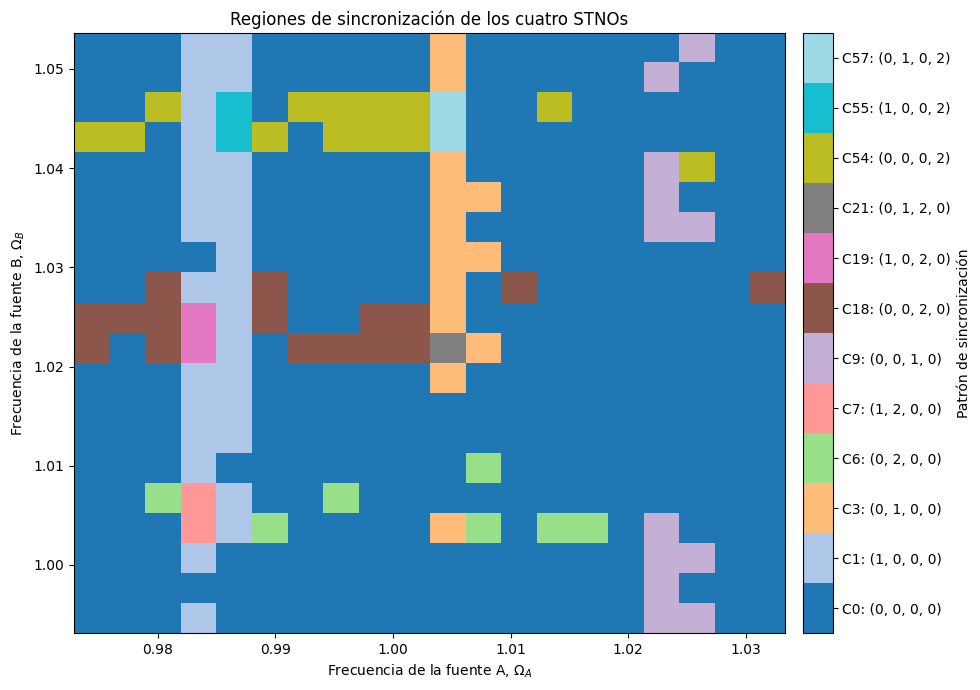

In [14]:
################################################################
#                             Mapa                             #
################################################################

Omega_A_val=np.linspace(Omega_libres_red[0]-0.01, Omega_libres_red[2]+0.01, 20)                    #Arreglo de 20 frecuencias externas A que van desde la frecuencia natural libre del oscilador 1 -0.01 a la frecuencia natural libre del oscilador 3 +0.01
Omega_B_val=np.linspace(Omega_libres_red[1]-0.01, Omega_libres_red[3]+0.01, 20)   
mapa_codigos = np.zeros((len(Omega_B_val), len(Omega_A_val)), dtype=int)                           #Mapa 20*20
patrones_encontrados={}                                                                            #Diccionario vacio que nos permitira almacenar los patrones encontrados
patrones_totales=(len(Omega_A_val)*len(Omega_B_val))                                               #Numero de patrones posibles (400)
contador=0

for j, Omega_B_actual in enumerate(Omega_B_val):                                                   #Ciclo que barre las frecuencias en cuestion
    for i, Omega_A_actual in enumerate(Omega_A_val):
        patron_actual=Patron_particular(Omega_A_actual, Omega_B_actual)                            #Para cierta frecuencia B y frecuencia A obtengo el patron
        codigo_actual=codificacion(patron_actual)                                                  #Codifico el patron
        mapa_codigos[j, i]=codigo_actual                                                           #Asigno una posicion al codigo
        patrones_encontrados[int(codigo_actual)] = tuple(int(estado) for estado in patron_actual)  #Construimos el patron en una tupla para asi poder utilizarla como una clave en el diccionario
        contador += 1

print("Patrones de sincronización encontrados:")

for codigo, patron in sorted(patrones_encontrados.items()):                                        #Todo elemento del diccionario tiene un codigo y patron asociado, los escribo para conocerlos
    print(f"Código {codigo:2d}: {patron}")

#Elementos del mapa de sincronizacion (colores)

codigos_presentes=np.unique(mapa_codigos)                                                          #Sacamos todos los codigos presentes en el mapa y los ordenamos de menor a mayor
indice_colores=np.zeros_like(mapa_codigos)                                                         #Creamos una matriz nula con la misma cantidad de elementos que nuestro mapa para posteriormente asociar un color a cada patron

for indice, codigo in enumerate(codigos_presentes):                                                #Recorre los codigos ordenados para asignarle un indice que representara el estado de sincronizacion con un color
    indice_colores[mapa_codigos == codigo]=indice

colores=plt.cm.tab20(np.linspace(0.0,1.0,len(codigos_presentes)))                                  #Toma la misma cantidad de colores distintos como de patrones distintos
mapa_colores=ListedColormap(colores)                                                               #Construye un mapa de colores con la variable anterior

#Mapa de sincronizacion

def decodificar_patron(codigo):
    codigo = int(codigo)

    return (codigo % 3,(codigo // 3) % 3,(codigo // 9) % 3,(codigo // 27) % 3)

plt.figure(figsize=(10, 7))

imagen = plt.imshow(indice_colores, origin="lower", aspect="auto", extent=[Omega_A_val[0], Omega_A_val[-1], Omega_B_val[0], Omega_B_val[-1]], cmap=mapa_colores, interpolation="nearest", vmin=-0.5, vmax=len(codigos_presentes) - 0.5)

plt.xlabel(r"Frecuencia de la fuente A, $\Omega_A$")
plt.ylabel(r"Frecuencia de la fuente B, $\Omega_B$")
plt.title("Regiones de sincronización de los cuatro STNOs")

etiquetas_patrones=[f"C{int(codigo)}: {decodificar_patron(codigo)}" for codigo in codigos_presentes]           #Crea una etiqueta para cada codigo presente
barra_colores=plt.colorbar(imagen, ticks=np.arange(len(codigos_presentes)), pad=0.02)                           #Crea la barra de colores discreta
barra_colores.ax.set_yticklabels(etiquetas_patrones)                                                            #Muestra el codigo y el patron en cada color
barra_colores.set_label("Patrón de sincronización")

plt.tight_layout()
plt.show()

Se obtiene de forma exitosa un mapa de sincronizacion basico, con baja resolucion por el tamaño de la malla (400). Sin embargo, aun no hemos aplicado ningun tipo de entrenamiento, puesto que los unicos parametros fisicos controlables estan fijos (las corrientes de entrada en los STNOs). Entonces, ahora buscamos entrenar estas corrientes:

In [53]:
Irazon_red=np.array([1.5, 1.5, 1.5, 1.5], dtype=float)                                  #Defino 4 corrientes (proporciones)
s_ss_red=np.sqrt((Irazon_red-1)/Q)                                                      #Radios estacionarios
Omega_libres_red=Omega_0*(1+N_0*s_ss_red**2)                                            #Frecuencias de STNOs libres

################################################################
#            Redefiniendo funciones para la red                #
################################################################

def frec_ss(Omega_A, Omega_B, Irazon_red, tau_final, pasos):
    s_iniciales=np.sqrt((Irazon_red-1)/Q)                                           #Arreglo de radios estacionarios
    theta_iniciales=np.array([0, 0.05, 0.1, 0.15])                                  #Elijo un desfase minimo entre osciladores
    y_inicial=np.empty(2*Num_STNO)                                                  #Vector de 8 elementos itercalados y=(s_1, theta_1,...,s_4, theta_4)
    y_inicial[0::2]=s_iniciales
    y_inicial[1::2]=theta_iniciales
    tau_evaluado=np.linspace(0, tau_final, pasos)                                   #Arreglo de tiempos
    solucion=solve_ivp(fun=red_4_STNOs, t_span=(0.0, tau_final), y0=y_inicial, t_eval=tau_evaluado, args=(alpha, Q, N_0, Irazon_red, F_e, epsilon, Omega_0, Omega_A, Omega_B, psi_A, psi_B), method="RK45", rtol=1e-8, atol=1e-10)

    amplitudes = solucion.y[0::2]

    # Comprobamos únicamente el último 20 %
    Posiciones_ss = int(0.8 * len(solucion.t))
    amplitudes_ss = amplitudes[:, Posiciones_ss:]

    if np.any(np.abs(amplitudes_ss) < 1e-3):

        indice_STNO = np.unravel_index(
            np.argmin(np.abs(amplitudes_ss)),
            amplitudes_ss.shape
        )[0]

        amplitud_minima = np.min(
            np.abs(amplitudes_ss[indice_STNO])
        )

        raise RuntimeError(
            f"Simulación inválida: el STNO {indice_STNO + 1} "
            f"alcanzó |s| = {amplitud_minima:.3e} "
            "en el régimen estacionario."
        )
    
    tau_arreglo=solucion.t
    theta_sol=solucion.y[1::2]

    #Tomamos el ultimo 20% de la simulacion

    Posiciones_ss=int(0.8*len(tau_arreglo))
    tau_ss=tau_arreglo[Posiciones_ss:]
    theta_ss = theta_sol[:,Posiciones_ss:]

    #Frecuencias de los STNOs

    Omega_STNOs=(theta_ss[:, -1]-theta_ss[:, 0])/(tau_ss[-1]-tau_ss[0])             #Arreglo de frecuencias de los STNOs

    return (Omega_STNOs, tau_arreglo, solucion.y)

def Patron_particular(Omega_A, Omega_B, Irazon_red, tau_final=5000.0, numero_puntos=10000, tolerancia=1e-4):
    Omega_STNOs, _, _=frec_ss(Omega_A, Omega_B, Irazon_red, tau_final, numero_puntos)                      #Solo nos interesa las frecuencias de los STNOs
    patron=clasificacion(Omega_STNOs, Omega_A, Omega_B, tolerancia)

    return patron

################################################################
#             Funcion respuesta de la red                      #
################################################################

def respuesta_red(Omega_A, Omega_B, Irazon_red, tau_final=5000.0, numero_puntos=10000, tolerancia=tolerancia):              #Devuelve frecuencias y patron asociado
    Omega_STNOs, _, _=frec_ss(Omega_A, Omega_B, Irazon_red, tau_final, numero_puntos)
    patron=clasificacion(Omega_STNOs, Omega_A, Omega_B, tolerancia)

    return Omega_STNOs, patron

""" ################################################################
#                             Mapa                             #
################################################################

Omega_A_val=np.linspace(Omega_libres_red[0]-0.01, Omega_libres_red[2]+0.01, 20)                    #Arreglo de 20 frecuencias externas A que van desde la frecuencia natural libre del oscilador 1 -0.01 a la frecuencia natural libre del oscilador 3 +0.01
Omega_B_val=np.linspace(Omega_libres_red[1]-0.01, Omega_libres_red[3]+0.01, 20)   
mapa_codigos = np.zeros((len(Omega_B_val), len(Omega_A_val)), dtype=int)                           #Mapa 20*20
patrones_encontrados={}                                                                            #Diccionario vacio que nos permitira almacenar los patrones encontrados
patrones_totales=(len(Omega_A_val)*len(Omega_B_val))                                               #Numero de patrones posibles (400)
contador=0

for j, Omega_B_actual in enumerate(Omega_B_val):                                                   #Ciclo que barre las frecuencias en cuestion
    for i, Omega_A_actual in enumerate(Omega_A_val):
        patron_actual=Patron_particular(Omega_A_actual, Omega_B_actual, Irazon_red)                            #Para cierta frecuencia B y frecuencia A obtengo el patron
        codigo_actual=codificacion(patron_actual)                                                  #Codifico el patron
        mapa_codigos[j, i]=codigo_actual                                                           #Asigno una posicion al codigo
        patrones_encontrados[int(codigo_actual)] = tuple(int(estado) for estado in patron_actual)  #Construimos el patron en una tupla para asi poder utilizarla como una clave en el diccionario
        contador += 1

print("Patrones de sincronización encontrados:")

for codigo, patron in sorted(patrones_encontrados.items()):                                        #Todo elemento del diccionario tiene un codigo y patron asociado, los escribo para conocerlos
    print(f"Código {codigo:2d}: {patron}")

#Elementos del mapa de sincronizacion (colores)

codigos_presentes=np.unique(mapa_codigos)                                                          #Sacamos todos los codigos presentes en el mapa y los ordenamos de menor a mayor
indice_colores=np.zeros_like(mapa_codigos)                                                         #Creamos una matriz nula con la misma cantidad de elementos que nuestro mapa para posteriormente asociar un color a cada patron

for indice, codigo in enumerate(codigos_presentes):                                                #Recorre los codigos ordenados para asignarle un indice que representara el estado de sincronizacion con un color
    indice_colores[mapa_codigos == codigo]=indice

colores=plt.cm.tab20(np.linspace(0.0,1.0,len(codigos_presentes)))                                  #Toma la misma cantidad de colores distintos como de patrones distintos
mapa_colores=ListedColormap(colores)                                                               #Construye un mapa de colores con la variable anterior

#Mapa de sincronizacion

def decodificar_patron(codigo):
    codigo = int(codigo)

    return (codigo % 3,(codigo // 3) % 3,(codigo // 9) % 3,(codigo // 27) % 3)

plt.figure(figsize=(10, 7))

imagen=plt.imshow(indice_colores, origin="lower", aspect="auto", extent=[Omega_A_val[0], Omega_A_val[-1], Omega_B_val[0], Omega_B_val[-1]], cmap=mapa_colores, interpolation="nearest", vmin=-0.5, vmax=len(codigos_presentes) - 0.5)

plt.xlabel(r"Frecuencia de la fuente A, $\Omega_A$")
plt.ylabel(r"Frecuencia de la fuente B, $\Omega_B$")
plt.title("Regiones de sincronización de los cuatro STNOs")

etiquetas_patrones=[f"C{int(codigo)}: {decodificar_patron(codigo)}" for codigo in codigos_presentes]            #Crea una etiqueta para cada codigo presente
barra_colores=plt.colorbar(imagen, ticks=np.arange(len(codigos_presentes)), pad=0.02)                           #Crea la barra de colores discreta
barra_colores.ax.set_yticklabels(etiquetas_patrones)                                                            #Muestra el codigo y el patron en cada color
barra_colores.set_label("Patrón de sincronización")

plt.tight_layout()
plt.show() """

<>:118: SyntaxWarning: invalid escape sequence '\O'
<>:118: SyntaxWarning: invalid escape sequence '\O'
C:\Users\A23\AppData\Local\Temp\ipykernel_15944\4035934487.py:118: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel(r"Frecuencia de la fuente A, $\Omega_A$")


' ################################################################\n#                             Mapa                             #\n################################################################\n\nOmega_A_val=np.linspace(Omega_libres_red[0]-0.01, Omega_libres_red[2]+0.01, 20)                    #Arreglo de 20 frecuencias externas A que van desde la frecuencia natural libre del oscilador 1 -0.01 a la frecuencia natural libre del oscilador 3 +0.01\nOmega_B_val=np.linspace(Omega_libres_red[1]-0.01, Omega_libres_red[3]+0.01, 20)   \nmapa_codigos = np.zeros((len(Omega_B_val), len(Omega_A_val)), dtype=int)                           #Mapa 20*20\npatrones_encontrados={}                                                                            #Diccionario vacio que nos permitira almacenar los patrones encontrados\npatrones_totales=(len(Omega_A_val)*len(Omega_B_val))                                               #Numero de patrones posibles (400)\ncontador=0\n\nfor j, Omega_B_actual in en

Ahora debemos entrenar las corrientes alternas entrantes en los distintos STNOs. La idea es determinar la frecuencias estacionaria de la red y su respectivo patron de sincronizacion con las frecuencias entrantespara asi compararlo medianto una metrica al patron asignado a cada vocal.

Por ejemplo, para la vocal o formarte "AE", el patron que entrerga el trabajo de Julie Grolier es:

$$
(1A, 3B)
$$

Esto quiere decir que el STNO 1 se sincronizo con la frecuencia A y el STNO 3 con la frecuencia B. Mediante el entrenamiento esto se ajusta mediante el vectorde diferencia: 

$$
\mathbf d_{\mathrm{AE}}
=
\begin{pmatrix}
\Omega_A-\Omega_1\\
0\\
\Omega_B-\Omega_3\\
0
\end{pmatrix}
$$

En otras palabras, cada componente mide cuanto debe desplazar la frecuencia de un STNO particular para cierta vocal o formante.

Para los otros formantes esto es tal que: 

$$
(3A, 1B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{AH}}
=
\begin{pmatrix}
\Omega_B-\Omega_1\\
0\\
\Omega_A-\Omega_3\\
0
\end{pmatrix} \qquad (AH)
$$

$$
(2A, 1B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{AW}}
=
\begin{pmatrix}
\Omega_B-\Omega_1\\
\Omega_A-\Omega_2\\
0\\
0
\end{pmatrix} \qquad (AW)
$$

$$
(1A, 2B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{ER}}
=
\begin{pmatrix}
\Omega_A-\Omega_1\\
\Omega_B-\Omega_2\\
0\\
0
\end{pmatrix} \qquad (ER)
$$

$$
(3B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{IH}}
=
\begin{pmatrix}
0\\
0\\
\Omega_B-\Omega_3\\
0
\end{pmatrix} \qquad (IH)
$$

$$
(4B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{IY}}
=
\begin{pmatrix}
0\\
0\\
0\\
\Omega_B-\Omega_4
\end{pmatrix} \qquad (IY)
$$

$$
(1B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{UW}}
=
\begin{pmatrix}
\Omega_B-\Omega_1\\
0\\
0\\
0
\end{pmatrix} \qquad (IY)
$$

In [40]:
################################################################
#                    Vectores Diferencia                       #
################################################################
 
patrones_objetivo={                                                          #Diccionario que contiene los patrones asociados a cada vocal
    "ae": np.array([1, 0, 2, 0], dtype=int),  #(1A, 3B)
    "ah": np.array([2, 0, 1, 0], dtype=int),  #(3A, 1B)
    "aw": np.array([2, 1, 0, 0], dtype=int),  #(2A, 1B)
    "er": np.array([1, 2, 0, 0], dtype=int),  #(1A, 2B)
    "ih": np.array([0, 0, 2, 0], dtype=int),  #(3B)
    "iy": np.array([0, 0, 0, 2], dtype=int),  #(4B)
    "uw": np.array([2, 0, 0, 0], dtype=int)   #(1B)
}

def vector_diferencia(vocal,Omega_A,Omega_B,Omega_STNOs,patron):
    objetivo=patrones_objetivo[vocal]                                     #Establecemos el patron objetivo (vocal que nos interesa ajustar)
    diferencia=np.zeros(Num_STNO, dtype=float)                            #Construyo vector diferencia nulo

    for i in range(Num_STNO):
        if objetivo[i]==1 and patron[i]!=1:                               #El STNO i se sincronizarse con la fuente A
            diferencia[i]=Omega_A-Omega_STNOs[i]

        elif objetivo[i]==2 and patron[i]!= 2:                            #El STNO i se sincronizarse con la fuente B
            diferencia[i]=Omega_B-Omega_STNOs[i]

    return diferencia



Para seguir lo que debemos hacer ahora es cargar el dataset que contiene las frecuencias de entradas y su respectivo aporte para la construccion de una vocal. Este material contiene 37 pares de frecuencia $(f_{A}, f_{B})$ para cada una de las siete clases de vocales (Expresadas en MHz).
Como el modelo dinámico emplea frecuencias adimensionales, se define una
frecuencia de referencia

$$
f_{\mathrm{ref}}=350\ \mathrm{MHz},
$$

y se realiza la transformación

$$
\Omega_A=\frac{F_A}{f_{\mathrm{ref}}},
\qquad
\Omega_B=\frac{F_B}{f_{\mathrm{ref}}}.
$$

Debemos hacer esta transformacion por que las frecuencias externas son mucho mayores a la frecuencia interna del sistema (STNOs).

En la siguiente etapa eligiremos una muestra de cada vocal, ya que posterioemente debemos entrenar el algoritmo considerando simultaneamente las correciones de cada vocal (estan acopladas). Es decir, para cada vocal hacemos:

$$
(\Omega_A,\Omega_B)_{\text{muestra}}
\qquad \longrightarrow \qquad
\text{Integración de las ecuaciones diferenciales de los 4 STNOs}
\qquad \longrightarrow \qquad
\text{Frecuencias estacionarias de los osciladores}
$$

Luego de obtener las frecuencias de los STNOs analizamos si existe sincronizacion con alguna fuente para posteriormente comparar este resultado con el patron objetivo (patron de la vocal). Por ultimo, sumamos las diferencias exigidas en cada vocal (suma de vectores diferencia) para obtener un signo que nos dira a que lado debemos desplazar la frecuencia de un oscilador i (+, -, nulo):

$$
S=\sum_{i}d_{i}=d_{ae}+d_{ah}+d_{aw}+d_{er}+d_{ih}+d_{iy}+d_{uw}
$$

$$
D_{i}=D_i =
\begin{cases}
+1, & S_i > 0,\\
0, & S_i = 0,\\
-1, & S_i < 0.
\end{cases}
$$

In [41]:
################################################################
#                  Carga del dataset                           #
################################################################

from docx import Document

archivo_dataset=r"C:\Users\A23\Downloads\41586_2018_632_MOESM2_ESM (5).docx"
documento=Document(archivo_dataset)
tabla=documento.tables[2]                                           #La tercera tabla contiene los pares f_{A} y f_{B} de las siete vocales
datos=[]                                                            #Para guardar las filas de la tabla 3
   
for fila in tabla.rows[1:]:                                         #Guardamos las filas de la tabla (omitimos la primera porque es el encabezaedo)
    datos.append([float(celda.text.strip()) for celda in fila.cells])

datos=np.array(datos, dtype=float)                                  #Lista a arreglo

################################################################
#              Organización del dataset                        #
################################################################

vocales=["ae", "ah", "aw", "er", "ih", "iy", "uw"]
frecuencia_referencia=350.0                                         #Frecuencia para establecer unidades adimensionales de frecuencias
tolerancia=0.5/frecuencia_referencia
dataset_vocales={}                                                  #Creamos un diccionario donde cada clave sera una vocal y contendra sus respectivos 37 pares de frecuencias entrantes

for i, vocal in enumerate(vocales):
    FA=datos[:, 2*i]                                                         #Tomamos la columna referente a la frecuencia f_A y f_B
    FB=datos[:, 2*i + 1]
    Omega_A=FA/frecuencia_referencia                                         #Adimensional
    Omega_B=FB/frecuencia_referencia
    dataset_vocales[vocal]=np.column_stack((Omega_A, Omega_B))               #Construye arreglo de 37 filas y dos columnas (f_A, f_B)

################################################################
#       Selección de una muestra de cada vocal                 #
################################################################

def seleccionar_muestras(dataset_vocales):                                   #Esta funcion simplemente nos entrega muestras aleatorias para el entranmiento de cada vocal
    muestras={}

    for vocal in vocales:                                                    #Recorre cada vocal y establece una muestra
        indice=np.random.randint(len(dataset_vocales[vocal]))                #Elige aleatoriamente una de las 37 muestras para cada vocal
        muestras[vocal]=dataset_vocales[vocal][indice]                       #Se guarda el par de frecuencia externas asociada a esa muestra

    return muestras

muestras=seleccionar_muestras(dataset_vocales)                               #Seleccionamos una muestra aleatoria de cada clase de vocal 

################################################################
#        Vectores diferencia de las siete vocales              #
################################################################

def diferencias_entrenamiento(muestras, Irazon_red):
    diferencias={}                                                           #Diccionario para guardar las diferencia de cada clase

    for vocal in vocales:
        Omega_A, Omega_B=muestras[vocal]                                     #Para una vocal recuperamos el par de frecuencias externas
        Omega_STNOs, patron=respuesta_red(Omega_A, Omega_B, Irazon_red)      #Respuesta de la red al interactuar con las dos frecuencias externas
        diferencias[vocal]=vector_diferencia(vocal, Omega_A, Omega_B, Omega_STNOs, patron)     #Comparamos patrones y obtenemos una diferencia de frecuencias para mcierta vocal

    return diferencias

diferencias=diferencias_entrenamiento(muestras, Irazon_red)                  #Se calcula un vector diferencia para cada vocal

for vocal in vocales:
    print(vocal, diferencias[vocal])

suma_diferencias=np.sum(list(diferencias.values()), axis=0)                  #Sumamos las correcciones por las siete vocales (las vocales no se pueden tratar de manera independiente, acopladas)

D=np.sign(suma_diferencias)                                                  #Obtenemos el signo de cada componente de la suma anterior para posteriormente entrenar el modelo con descenso de gradiente

print("Suma de diferencias:", suma_diferencias)
print("Dirección de corrección D:", D)

ae [-0.00337   0.       -0.013318  0.      ]
ah [-0.014679  0.       -0.015768  0.      ]
aw [-0.009487 -0.011481  0.        0.      ]
er [-0.009929 -0.015487  0.        0.      ]
ih [ 0.        0.       -0.015405  0.      ]
iy [ 0.        0.        0.       -0.007623]
uw [-0.011417  0.        0.        0.      ]
Suma de diferencias: [-0.048883 -0.026968 -0.044491 -0.007623]
Dirección de corrección D: [-1. -1. -1. -1.]


Ahora si podemos comenzar a entrenar el modelo. Queremos que las corrientes de entreda se modifiquen por cada iteracion si es necesario. Para ello, los autores utilizan la regla:

$$
I_i^{n+1}
=
I_i^n
+
\mu D_i\,
\operatorname{sgn}\left(
\left.\frac{\partial \Omega_i}{\partial I_i}\right|_{I_i}
\right)
$$ 

Donde $\mu$ es el paso o la tasa de aprendizaje.

In [51]:
################################################################
#             Actualizacion de las corrientes                  #
################################################################

mu=0.1                                                 #Utilizado por los autores

def Entrenamiento(dataset_vocales, Irazon_red, mu):
    muestras=seleccionar_muestras(dataset_vocales)                     #Seleccionamos muestra aleatoria de cada vocal

    try:
        diferencias=diferencias_entrenamiento(muestras, Irazon_red)    #Simulamos red y obtenemos el vector diferencia de cada vocal

    except RuntimeError as error:
        print(error)
        print("Iteración rechazada: las corrientes no cambian.")
        diferencias = {
            vocal: np.zeros(Num_STNO)
            for vocal in vocales
        }

        suma_diferencias = np.zeros(Num_STNO)
        D = np.zeros(Num_STNO)

        return (
            Irazon_red.copy(),
            muestras,
            diferencias,
            suma_diferencias,
            D
        )
    
    suma_diferencias=np.sum(list(diferencias.values()), axis=0)        #Sumamos componentes de las correcciones de cada vocal
    D=np.sign(suma_diferencias)                                        #Nos da la direccion de actualizacion de la corriente

    pendiente_frecuencia=Omega_0*N_0/Q                                 #Queremos ver como responde la frecuencia libre de cada STNO frente a un cambio de corriente entrante
    signo_pendiente=np.sign(pendiente_frecuencia)

    paso=mu*D*signo_pendiente                                          #Actualizacion de corriente
    Irazon_nueva=Irazon_red+paso

    return (Irazon_nueva, muestras, diferencias, suma_diferencias, D)

Recordemos que al modificar las corrientes entrantes tambien cambian las frecuencias naturales de los STNOs: 

$$
\Omega_{i}=\Omega_{0,i}\left[ 1+\frac{N_0}{Q}(I_{i}-1) \right]
$$

Por lo tanto, la region de sincronizacion tambien debe desplazarse. La idea del entrenamiento es mover estas regiones hasta que los conjuntos asociados a cada vocal produzcan los patrones correspondientes.

In [44]:
################################################################
#                        Entrenamiento                         #
################################################################

def entrenar_red(dataset_vocales, Irazon_inicial, mu, N_iteraciones):

    # Copiamos las corrientes iniciales para no modificar
    # accidentalmente el arreglo original.
    Irazon_actual = np.array(
        Irazon_inicial,
        dtype=float
    ).copy()

    # Guardamos las corrientes desde el estado inicial.
    historial_corrientes = [Irazon_actual.copy()]

    # También almacenamos la dirección de corrección y la suma
    # de los vectores diferencia obtenidas en cada iteración.
    historial_D = []
    historial_sumas = []

    for iteracion in range(N_iteraciones):

        # Ejecutamos una iteración completa:
        # selección, simulación, comparación y actualización.
        resultado = Entrenamiento(
            dataset_vocales,
            Irazon_actual,
            mu
        )

        (
            Irazon_nueva,
            muestras,
            diferencias,
            suma_diferencias,
            D
        ) = resultado

        # Guardamos la información antes de continuar.
        historial_corrientes.append(Irazon_nueva.copy())
        historial_D.append(D.copy())
        historial_sumas.append(suma_diferencias.copy())

        # Las corrientes nuevas pasan a ser las corrientes
        # de entrada de la siguiente iteración.
        Irazon_actual = Irazon_nueva

        print(
            f"Iteración {iteracion + 1}: "
            f"I/Ith = {Irazon_actual}"
        )

    return (
        Irazon_actual,
        np.array(historial_corrientes),
        np.array(historial_D),
        np.array(historial_sumas)
    )

################################################################
#              Prueba corta del entrenamiento                  #
################################################################

Irazon_inicial = np.array([1.5, 1.5, 1.5, 1.5])

mu = 0.1
N_iteraciones = 3

(
    Irazon_entrenada,
    historial_corrientes,
    historial_D,
    historial_sumas
) = entrenar_red(
    dataset_vocales,
    Irazon_inicial,
    mu,
    N_iteraciones
)

print("\nHistorial de corrientes:")
print(historial_corrientes)

print("\nHistorial de direcciones:")
print(historial_D)

print("\nHistorial de sumas:")
print(historial_sumas)

Iteración 1: I/Ith = [1.4 1.4 1.4 1.4]
Iteración 2: I/Ith = [1.3 1.3 1.3 1.3]
Iteración 3: I/Ith = [1.2 1.3 1.2 1.2]

Historial de corrientes:
[[1.5 1.5 1.5 1.5]
 [1.4 1.4 1.4 1.4]
 [1.3 1.3 1.3 1.3]
 [1.2 1.3 1.2 1.2]]

Historial de direcciones:
[[-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1.  0. -1. -1.]]

Historial de sumas:
[[-0.032842 -0.008486 -0.042983 -0.018853]
 [-0.035636 -0.027302 -0.020151 -0.008982]
 [-0.014683  0.       -0.017114 -0.013824]]


In [55]:
################################################################
#             Una iteración adicional de prueba                #
################################################################

Irazon_entrenada = np.array([1.3, 1.3, 1.3, 1.3])

resultado = Entrenamiento(
    dataset_vocales,
    Irazon_entrenada,
    mu
)

(
    Irazon_siguiente,
    muestras,
    diferencias,
    suma_diferencias,
    D
) = resultado

print("Corrientes actuales:", Irazon_entrenada)
print("Suma de diferencias:", suma_diferencias)
print("Dirección D:", D)
print("Corrientes propuestas:", Irazon_siguiente)

print("\nDiferencias por vocal:")
for vocal in vocales:
    print(vocal, diferencias[vocal])

Corrientes actuales: [1.3 1.3 1.3 1.3]
Suma de diferencias: [-0.030241 -0.004509 -0.02785  -0.01342 ]
Dirección D: [-1. -1. -1. -1.]
Corrientes propuestas: [1.2 1.2 1.2 1.2]

Diferencias por vocal:
ae [-0.004379  0.       -0.007763  0.      ]
ah [-0.007833  0.       -0.01105   0.      ]
aw [-0.006785 -0.004509  0.        0.      ]
er [-0.011245  0.        0.        0.      ]
ih [ 0.        0.       -0.009037  0.      ]
iy [ 0.       0.       0.      -0.01342]
uw [0. 0. 0. 0.]


In [62]:
################################################################
#       Actualización acumulativa de las corrientes             #
################################################################

mu_prueba = 0.01
signo_pendiente = np.sign(Omega_0 * N_0 / Q)

Irazon_acumulada = Irazon_entrenada.copy()

for i in range(Num_STNO):

    Irazon_candidata = Irazon_acumulada.copy()

    Irazon_candidata[i] += (
        mu_prueba
        * D[i]
        * signo_pendiente[i]
    )

    print("\n" + "=" * 55)
    print(f"Intentando actualizar el STNO {i + 1}")
    print("Corrientes candidatas:", Irazon_candidata)

    try:
        diferencias_entrenamiento(
            muestras,
            Irazon_candidata
        )

        Irazon_acumulada = Irazon_candidata.copy()
        print("Actualización aceptada.")

    except RuntimeError as error:
        print(error)
        print(f"Actualización del STNO {i + 1} rechazada.")

print("\nCorrientes finales de la prueba:", Irazon_acumulada)


Intentando actualizar el STNO 1
Corrientes candidatas: [1.29 1.3  1.3  1.3 ]
Actualización aceptada.

Intentando actualizar el STNO 2
Corrientes candidatas: [1.29 1.29 1.3  1.3 ]
Simulación inválida: el STNO 2 alcanzó |s| = 1.110e-05 en el régimen estacionario.
Actualización del STNO 2 rechazada.

Intentando actualizar el STNO 3
Corrientes candidatas: [1.29 1.3  1.29 1.3 ]
Actualización aceptada.

Intentando actualizar el STNO 4
Corrientes candidatas: [1.29 1.3  1.29 1.29]
Actualización aceptada.

Corrientes finales de la prueba: [1.29 1.3  1.29 1.29]


In [54]:
Irazon_diagnostico = np.array([1.3, 1.3, 1.3, 1.3])

################################################################
#     Diagnóstico de las respuestas anómalas de la red          #
################################################################

casos_anomalos = ["aw", "ih", "iy"]

tolerancia_sincronizacion = 0.5 / 350.0

for vocal in casos_anomalos:

    Omega_A, Omega_B = muestras[vocal]

    Omega_STNOs, tau, solucion_y = frec_ss(
        Omega_A,
        Omega_B,
        Irazon_diagnostico,
        tau_final=5000.0,
        pasos=10000
    )

    # En tu código:
    # y = (s1, theta1, s2, theta2, s3, theta3, s4, theta4)

    amplitudes = solucion_y[0::2]
    fases = solucion_y[1::2]

    # Último 20 % de la integración
    inicio_ss = int(0.8 * len(tau))
    amplitudes_ss = amplitudes[:, inicio_ss:]

    patron = clasificacion(
        Omega_STNOs,
        Omega_A,
        Omega_B,
        tolerancia_sincronizacion
    )

    print("\n" + "=" * 60)
    print(f"VOCAL: {vocal}")
    print(f"Entrada: Omega_A={Omega_A:.6f}, Omega_B={Omega_B:.6f}")

    print("\nFrecuencias estacionarias:")
    print(Omega_STNOs)

    print("\nPatrón obtenido:")
    print(patron)

    print("\nAmplitud mínima durante toda la integración:")
    print(np.min(amplitudes, axis=1))

    print("\nAmplitud mínima durante el último 20 %:")
    print(np.min(amplitudes_ss, axis=1))

    print("\nAmplitud máxima durante el último 20 %:")
    print(np.max(amplitudes_ss, axis=1))

    print("\nAmplitudes finales:")
    print(amplitudes[:, -1])

C:\Users\A23\AppData\Local\Temp\ipykernel_15944\4035934487.py:118: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel(r"Frecuencia de la fuente A, $\Omega_A$")


KeyboardInterrupt: 